# Dr.Spider Robustness Comparison

Grouped bar charts for the most important **Dr.Spider perturbation sets**, comparing the original pre-perturbation accuracy, lexical post-perturbation accuracy, and hybrid post-perturbation accuracy.

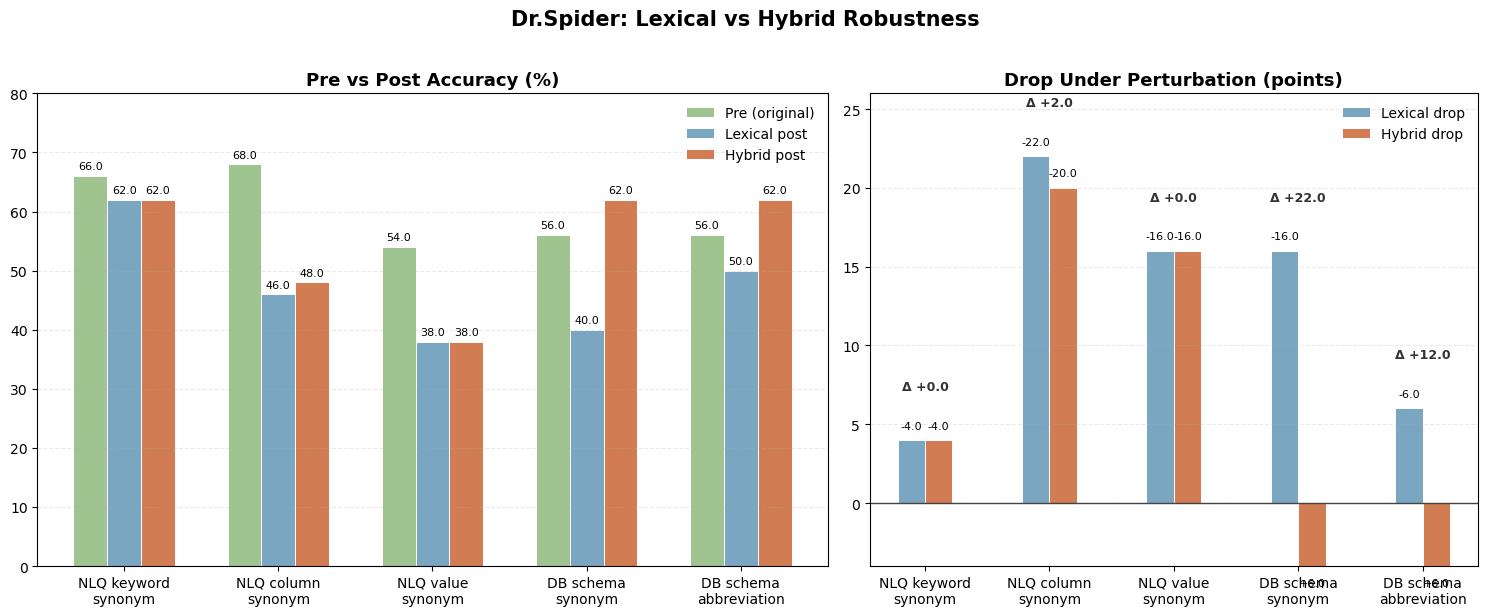

In [5]:
import matplotlib.pyplot as plt
import numpy as np

perturbations = [
    "NLQ keyword\nsynonym",
    "NLQ column\nsynonym",
    "NLQ value\nsynonym",
    "DB schema\nsynonym",
    "DB schema\nabbreviation",
]

pre = np.array([66.0, 68.0, 54.0, 56.0, 56.0])
lexical_post = np.array([62.0, 46.0, 38.0, 40.0, 50.0])
hybrid_post = np.array([62.0, 48.0, 38.0, 62.0, 62.0])

lexical_drop = pre - lexical_post
hybrid_drop = pre - hybrid_post
improvement = hybrid_post - lexical_post

series = [
    ("Pre (original)", pre, "#9fc490"),
    ("Lexical post", lexical_post, "#7aa6c2"),
    ("Hybrid post", hybrid_post, "#d17c52"),
] 

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1.3, 1.0]},
)

x = np.arange(len(perturbations))
width = 0.22

for i, (label, values, color) in enumerate(series):
    offset = (i - 1) * width
    axes[0].bar(x + offset, values, width=width, color=color, label=label, edgecolor="white", linewidth=0.7)

axes[1].bar(x - width/2, lexical_drop, width=width, color="#7aa6c2", label="Lexical drop", edgecolor="white", linewidth=0.7)
axes[1].bar(x + width/2, hybrid_drop, width=width, color="#d17c52", label="Hybrid drop", edgecolor="white", linewidth=0.7)

axes[0].set_title("Pre vs Post Accuracy (%)", fontsize=13, weight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(perturbations, fontsize=10)
axes[0].set_ylim(0, 80)
axes[0].grid(axis="y", linestyle="--", alpha=0.25)
axes[0].legend(frameon=False, loc="upper right")

axes[1].axhline(0, color="#444444", linewidth=1)
axes[1].set_title("Drop Under Perturbation (points)", fontsize=13, weight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(perturbations, fontsize=10)
axes[1].set_ylim(-4, 26)
axes[1].grid(axis="y", linestyle="--", alpha=0.25)
axes[1].legend(frameon=False, loc="upper right")

for i, (label, values, color) in enumerate(series):
    offset = (i - 1) * width
    for j, val in enumerate(values):
        axes[0].text(j + offset, val + 0.8, f"{val:.1f}", ha="center", va="bottom", fontsize=8)

for j, val in enumerate(lexical_drop):
    axes[1].text(j - width/2, val + 0.6, f"-{val:.1f}", ha="center", va="bottom", fontsize=8)
for j, val in enumerate(hybrid_drop):
    axes[1].text(j + width/2, val + 0.6, f"-{val:.1f}" if val >= 0 else f"+{-val:.1f}", ha="center", va="bottom", fontsize=8)

for j, val in enumerate(improvement):
    axes[1].text(j, max(lexical_drop[j], hybrid_drop[j]) + 3.0, f"Δ {val:+.1f}", ha="center", va="bottom", fontsize=9, weight="bold", color="#333333")

fig.suptitle("Dr.Spider: Lexical vs Hybrid Robustness", fontsize=15, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["wrong_column", "wrong_table", "extra_clause", "missing_clause"]
hintjoin = np.array([141, 32, 43, 9])
colfix   = np.array([115, 39, 39, 8])

x = np.arange(len(categories))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, hintjoin, width, label="hintjoin_v3", color="#7aa6c2", edgecolor="white", linewidth=0.7)
b2 = ax.bar(x + width/2, colfix,   width, label="colfix_v5",   color="#d17c52", edgecolor="white", linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel("Error count")
ax.set_title("Error counts by category: hintjoin_v3 vs colfix_v5", fontsize=13, weight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.legend(frameon=False)
ax.set_ylim(0, max(hintjoin.max(), colfix.max()) * 1.15)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f"{int(h)}",
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

difficulties = ["Easy", "Medium", "Hard", "Extra", "Overall"]

conditions = [
    ("Hard mask, no hints",     [37.5, 11.3, 21.2, 15.0, 21.2], "#9fc490"),
    ("Semantic mask, no hints", [36.2, 21.2, 23.7, 28.7, 27.5], "#7aa6c2"),
    ("Hard mask + hints",       [46.3, 45.0, 41.2, 22.5, 38.8], "#d17c52"),
    ("Semantic mask + hints",   [41.2, 36.2, 42.5, 25.0, 36.2], "#b58dc7"),
]

x = np.arange(len(difficulties))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 5.5))

for i, (label, values, color) in enumerate(conditions):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, values, width, label=label, color=color, edgecolor="white", linewidth=0.7)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.6, f"{h:.1f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(difficulties, fontsize=11)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy by masking condition and difficulty", fontsize=13, weight="bold")
ax.set_ylim(0, 55)
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.legend(frameon=False, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()